# Ejercicio 12: Multimodal Embeddings

Aubertin Ochoa    
13/07/2026

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

### Requisitos

In [1]:
!pip install transformers torch torchvision Pillow scikit-learn matplotlib seaborn

## Paso 1: Inicializar el Modelo y Procesar los Datos

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# 1. Cargamos el modelo CLIP y su procesador
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# 2. Definimos nuestros textos e imágenes de prueba
texts = ["A photo of a dog", "A cute cat sleeping", "A red sports car"]
image_paths = ["imagenes/dog.jpg", "imagenes/cat.jpg", "imagenes/car.jpg"]
images = [Image.open(path) for path in image_paths]

c:\Users\auber\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\auber\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\auber\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python a

## Paso 2: Obtener los Embeddings y Verificar el Espacio Vectorial

In [ ]:
# Procesamos los inputs con el procesador de CLIP
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)

# Extraemos los embeddings sin calcular gradientes (modo inferencia)
with torch.no_grad():
    # 1. Obtenemos las salidas del modelo
    image_outputs = model.get_image_features(inputs['pixel_values'])
    text_outputs = model.get_text_features(inputs['input_ids'], attention_mask=inputs['attention_mask'])
    
    # 2. Extraemos el tensor base si es un objeto contenedor, si ya es un tensor lo dejamos igual
    image_features = image_outputs.pooler_output if hasattr(image_outputs, 'pooler_output') else image_outputs
    text_features = text_outputs.pooler_output if hasattr(text_outputs, 'pooler_output') else text_outputs
    
    # 3. Ahora sí, normalizamos de forma segura 
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# Verificación de dimensiones 
print(f"Dimensión de los embeddings de Imagen: {image_features.shape}")
print(f"Dimensión de los embeddings de Texto: {text_features.shape}")

Dimensión de los embeddings de Imagen: torch.Size([3, 512])
Dimensión de los embeddings de Texto: torch.Size([3, 512])


## Paso 3: Proyectar los Vectores a 2D y Graficar

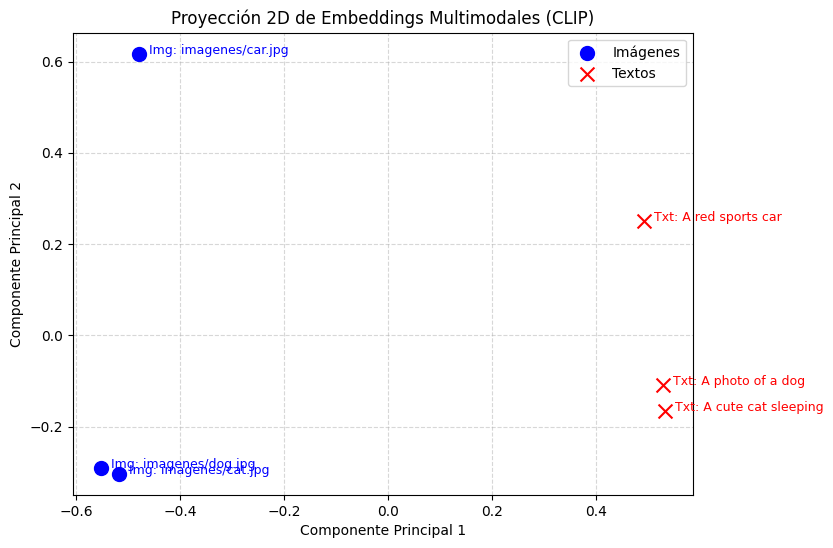

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Convertimos los tensores de PyTorch a arreglos de NumPy y los concatenamos
img_features_np = image_features.numpy()
txt_features_np = text_features.numpy()
all_features = np.vstack([img_features_np, txt_features_np])

# Aplicamos PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
all_features_2d = pca.fit_transform(all_features)

# Separamos los puntos proyectados otra vez en imágenes y textos
images_2d = all_features_2d[:len(images)]
texts_2d = all_features_2d[len(images):]

#  Graficar
plt.figure(figsize=(8, 6))

# Dibujar los puntos de imágenes
plt.scatter(images_2d[:, 0], images_2d[:, 1], color='blue', marker='o', s=100, label='Imágenes')
for i, path in enumerate(image_paths):
    plt.text(images_2d[i, 0] + 0.02, images_2d[i, 1], f"Img: {path}", fontsize=9, color='blue')

# Dibujar los puntos de textos
plt.scatter(texts_2d[:, 0], texts_2d[:, 1], color='red', marker='x', s=100, label='Textos')
for i, txt in enumerate(texts):
    plt.text(texts_2d[i, 0] + 0.02, texts_2d[i, 1], f"Txt: {txt}", fontsize=9, color='red')

plt.title("Proyección 2D de Embeddings Multimodales (CLIP)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

c:\Users\auber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\auber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\auber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


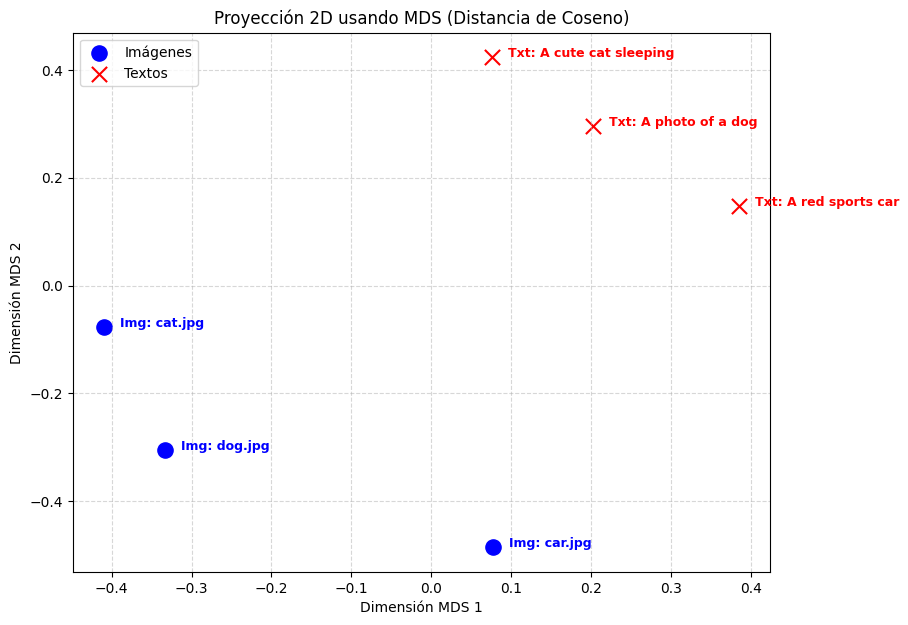

In [11]:
# EXTRA: Visualización alternativa usando MDS (Distancia de Coseno)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity

# 1. Juntamos los embeddings de imágenes y textos en una sola matriz
img_features_np = image_features.numpy()
txt_features_np = text_features.numpy()
all_features = np.vstack([img_features_np, txt_features_np])

# 2. Calculamos la matriz de distancias basada en Coseno (1 - Similitud)
# Usamos MDS porque respeta los ángulos entre vectores en lugar de la varianza
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
cosine_dist = 1 - cosine_similarity(all_features)

# 3. Proyectamos a las 2 dimensiones del plano
all_features_2d = mds.fit_transform(cosine_dist)
images_2d = all_features_2d[:len(images)]
texts_2d = all_features_2d[len(images):]

# 4. Graficamos los resultados
plt.figure(figsize=(9, 7))

# Puntos de las imágenes
plt.scatter(images_2d[:, 0], images_2d[:, 1], color='blue', marker='o', s=120, label='Imágenes')
for i, path in enumerate(image_paths):
    plt.text(images_2d[i, 0] + 0.02, images_2d[i, 1], f"Img: {path.split('/')[-1]}", fontsize=9, color='blue', weight='bold')

# Puntos de los textos
plt.scatter(texts_2d[:, 0], texts_2d[:, 1], color='red', marker='x', s=120, label='Textos')
for i, txt in enumerate(texts):
    plt.text(texts_2d[i, 0] + 0.02, texts_2d[i, 1], f"Txt: {txt}", fontsize=9, color='red', weight='bold')

plt.title("Proyección 2D usando MDS (Distancia de Coseno)")
plt.xlabel("Dimensión MDS 1")
plt.ylabel("Dimensión MDS 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Paso 4: Verificar Emparejamientos con Cosine Similarity

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculamos la matriz de similitud (Filas: Textos, Columnas: Imágenes)
similarity_matrix = cosine_similarity(txt_features_np, img_features_np)

print("Matriz de Similitud (Texto vs Imagen):")
print(similarity_matrix)
print("\n" + "="*40 + "\n")

# A. Búsqueda Texto -> Imagen
print("--- Búsqueda: Texto a Imagen ---")
for i, text in enumerate(texts):
    best_image_idx = np.argmax(similarity_matrix[i])
    print(f"Texto: '{text}' -> Mejor coincidencia: '{image_paths[best_image_idx]}' (Similitud: {similarity_matrix[i][best_image_idx]:.4f})")

print("\n" + "="*40 + "\n")

# B. Búsqueda Imagen -> Texto
print("--- Búsqueda: Imagen a Texto ---")
for j, img_path in enumerate(image_paths):
    best_text_idx = np.argmax(similarity_matrix[:, j])
    print(f"Imagen: '{img_path}' -> Mejor coincidencia: '{texts[best_text_idx]}' (Similitud: {similarity_matrix[best_text_idx][j]:.4f})")

Matriz de Similitud (Texto vs Imagen):
[[0.28429407 0.22310272 0.1632935 ]
 [0.1291345  0.3077773  0.13403723]
 [0.18071833 0.17399485 0.26977414]]


--- Búsqueda: Texto a Imagen ---
Texto: 'A photo of a dog' -> Mejor coincidencia: 'imagenes/dog.jpg' (Similitud: 0.2843)
Texto: 'A cute cat sleeping' -> Mejor coincidencia: 'imagenes/cat.jpg' (Similitud: 0.3078)
Texto: 'A red sports car' -> Mejor coincidencia: 'imagenes/car.jpg' (Similitud: 0.2698)


--- Búsqueda: Imagen a Texto ---
Imagen: 'imagenes/dog.jpg' -> Mejor coincidencia: 'A photo of a dog' (Similitud: 0.2843)
Imagen: 'imagenes/cat.jpg' -> Mejor coincidencia: 'A cute cat sleeping' (Similitud: 0.3078)
Imagen: 'imagenes/car.jpg' -> Mejor coincidencia: 'A red sports car' (Similitud: 0.2698)
